In [2]:
%load_ext autoreload
%autoreload 2

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from abm.rewards import *
from abm.rewards import _cholesky_grid, dog_rbf_landscape, _min_max, sinusoid_landscape
from abm.utils import plot_reward_grids, plot_reward_grid, rbf

# Reward landscape examples

This notebook contains examples from various kinds of reward landscapes:
- Spatially-correlated from Gaussian Process
- Gabor patches
- Difference of Gaussians (DoG)
- Spatially correlated + DoG superimposed

## 1. Correlated Reward Landscapes

We generate correlated reward landscapes where a 'parent' map defines the general structure, and 'children' maps are correlated with it.

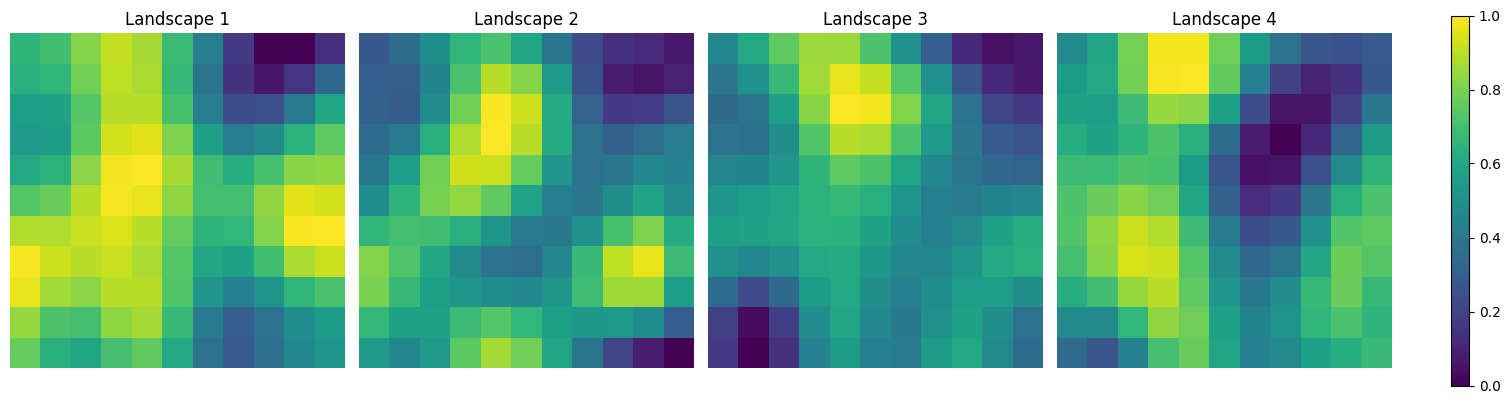

In [16]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 11

parent, children = make_parent_and_children_cholesky(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    length_scale=2.0
)

plot_reward_grids(np.array([parent] + children))
plt.show()

## 2. Gabor patches
We generate a parent Gabor landscape, and correlated children by generating with a new angle and mixing with parent

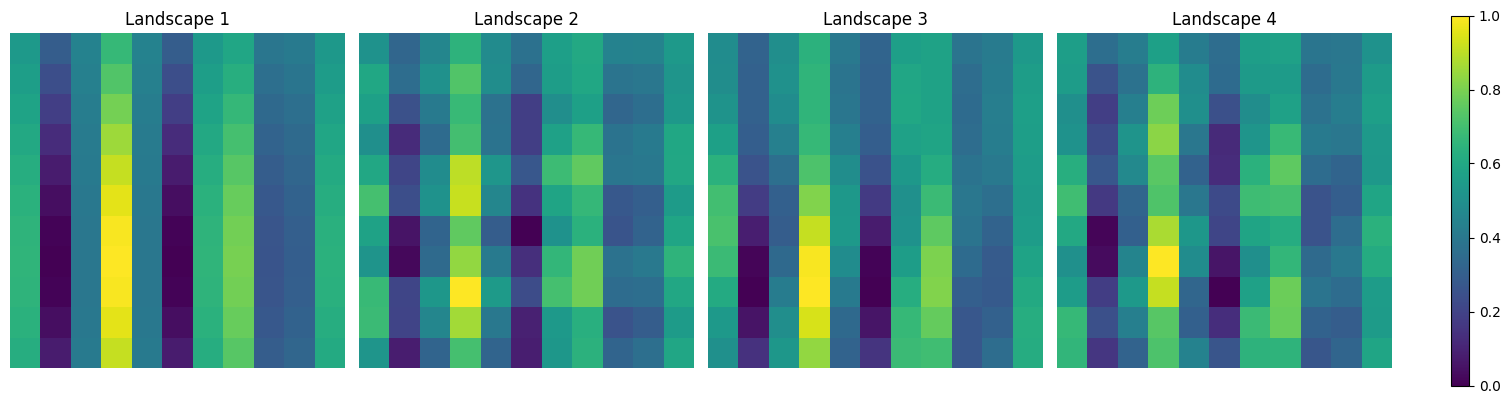

Correlations:


[np.float64(0.9499790754586327),
 np.float64(0.9552422314811077),
 np.float64(0.9495972194988955)]

In [9]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 11

parent, children = make_parent_and_children_gabor(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    frequency=3,
    sigma=5,
    theta_parent=0,
    phase_parent=0,
    correlation=0.95,
    center=(3.0, 3.0)
)

plot_reward_grids(np.array([parent] + children))
print('Correlations:')
check_correlations(parent, children, target_correlation=0.95, tol=0.1)[1]

## 3. Difference of Gaussians (DoG)
We generate a parent DoG landscape, and correlated children by jitetering parameters

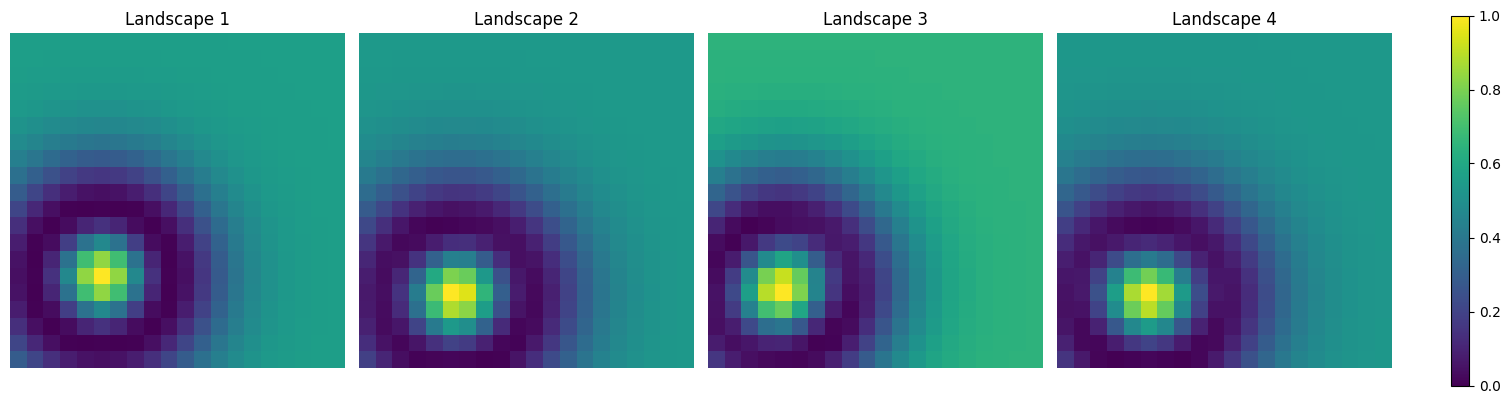

Correlations: [np.float64(0.9), np.float64(0.9000000000000002), np.float64(0.9000000000000002)]


In [43]:
rng = np.random.default_rng(42)
n_children = 3
grid_size = 20

parent, children = make_parent_and_children_mexican_hat(
    rng=rng,
    grid_size=grid_size,
    n_children=n_children,
    # frequency=3,
    sigma_inner=2,
    sigma_outer=4,
    correlation=0.9,
    center=(grid_size//4, grid_size//4)
)

plot_reward_grids(np.array([parent] + children))
print('Correlations:', check_correlations(parent, children, target_correlation=0.9, tol=0.1)[1])

## 4. Correlated DoG
We generate a base spatially-correlated landscape and superimpose a DoG kernel

In [275]:
rng = np.random.default_rng(24)
grid_size = 33
length_scale= 4.5
sigma_outer= 2.5
sigma_inner= 2.25

In [280]:
sin_reward = sinusoid_landscape(grid_size=grid_size, center=(grid_size//2, grid_size//2), sigma_inner=sigma_inner*2, sigma_outer=sigma_outer*2)
# dog_rbf = _min_max(dog_rbf)

# Make left and right subplots, heatmap on left and line plot on right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  
ax1.imshow(sin_reward, origin='lower', cmap='seismic')
ax1.plot([grid_size//2,grid_size//2+10],[grid_size//2,grid_size//2], color='red')
ax2.plot(sin_reward[grid_size//2, :], color='blue')
ax2.set_title('Cross-section of Sinusoid landscape')
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

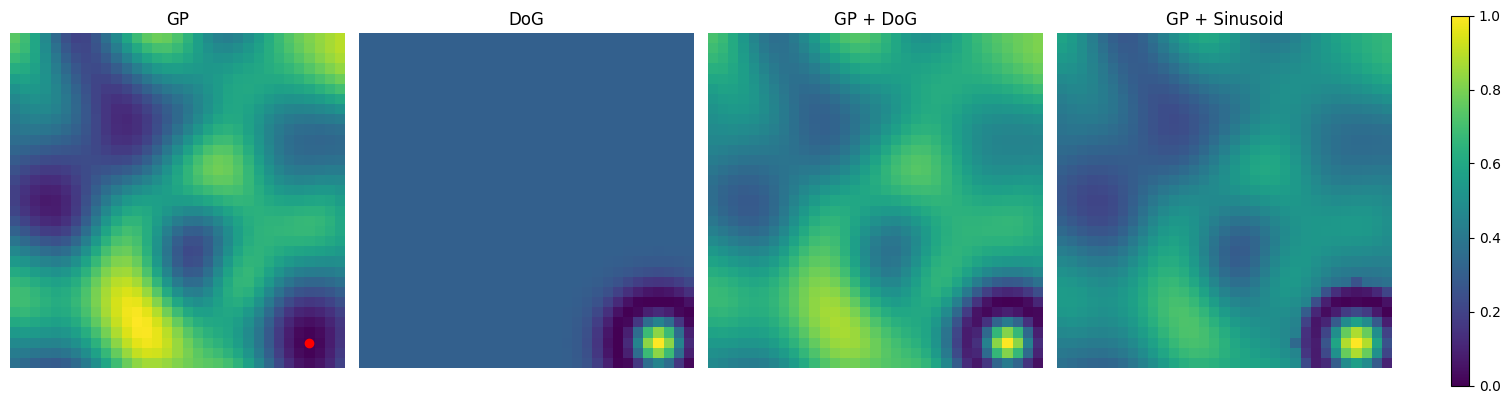

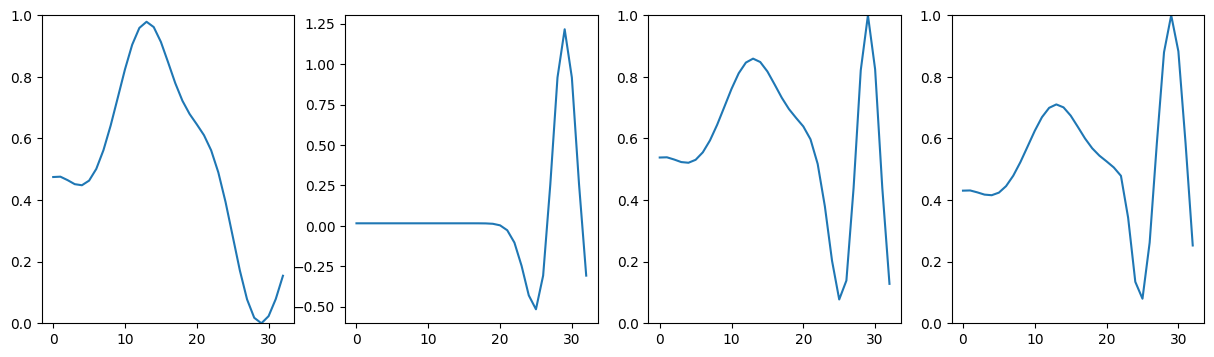

In [281]:
mix, gp, dog, (min_coords) = make_correlated_dog(
    rng, 
    grid_size=grid_size,
    length_scale=length_scale,
    sigma_outer=sigma_outer,
    sigma_inner=sigma_inner,
)
row, col = min_coords

# Generate single Gaussian at minimum of GP
sin_reward = sinusoid_landscape(grid_size=grid_size, center=min_coords, sigma_inner=sigma_inner*2, sigma_outer=sigma_outer*2)
gp_sin = _min_max(gp + sin_reward)

# Plot mixed landscape
fig, ax = plot_reward_grids(np.array([gp, dog, mix, gp_sin]), titles=['GP', 'DoG', 'GP + DoG', 'GP + Sinusoid'])
ax[0].plot(col, row, 'ro')
plt.show()

_, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].plot(gp[row,:])
ax[1].plot(dog[row,:])
ax[2].plot(mix[row,:])
ax[3].plot(gp_sin[row,:])
ax[0].set_ylim(0, 1)
ax[2].set_ylim(0, 1)
ax[3].set_ylim(0, 1)
plt.show()

## 5. Socially correlated correlated DoGs

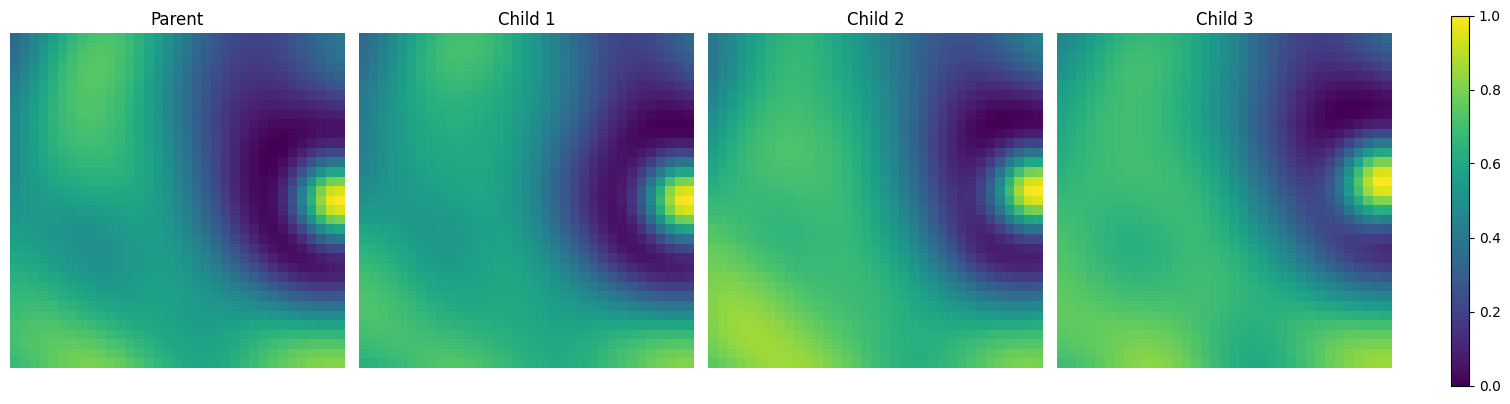

(np.False_,
 [np.float64(0.9678310604543182),
  np.float64(0.9542821861716522),
  np.float64(0.9157597393167992)])

In [261]:
rng = None # np.random.default_rng(42)
grid_size = 35
n_children = 3

parent, children, _ = make_parent_and_children_correlated_dog(
    rng, 
    grid_size=grid_size,
    n_children=n_children,
    length_scale=grid_size / 5,
    target_correlation=0.9,
)

plot_reward_grids(np.array([parent] + children), titles=['Parent'] + [f'Child {i+1}' for i in range(n_children)])
plt.show()

check_correlations(parent, children, target_correlation=0.6, tol=0.1)